## Imports

In [ ]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

I0000 00:00:1779023537.613248   40019 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779023537.829273   40019 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779023539.560067   40019 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1779023540.292034   40019 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## Load and preprocess

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Raw dataset shape: (60000, 28, 28)


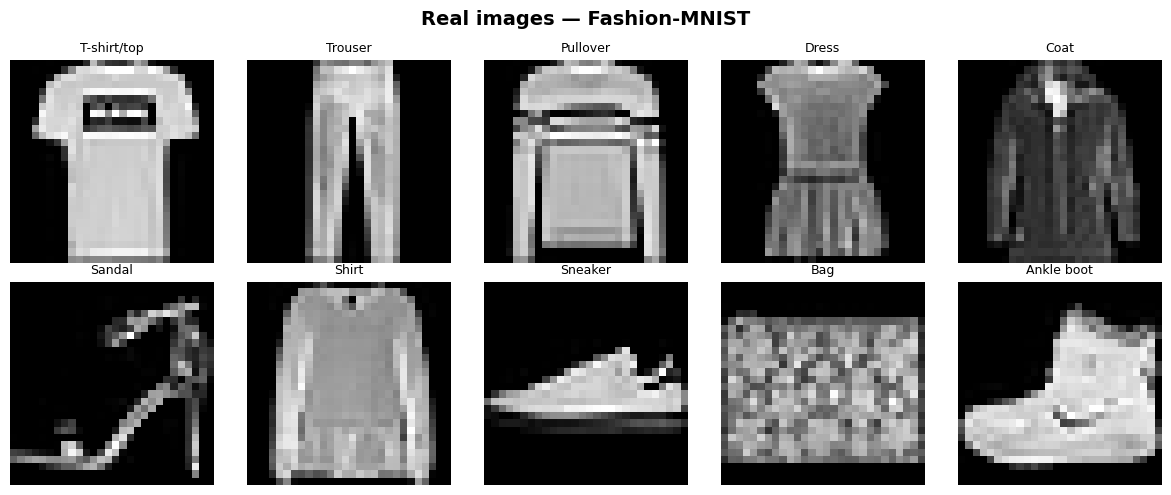

Values after normalization: min=-1.0, max=1.0


W0000 00:00:1779023560.433467   40019 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1779023560.605888   40019 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4500 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060, pci bus id: 0000:01:00.0, compute capability: 12.0a


Mini-batches per epoch: 234


In [ ]:
CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal",      "Shirt",   "Sneaker",  "Bag",   "Ankle boot"
]

# Load only the training split — the discriminator does not need labels
(X_train, y_train), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

print(f"\nRaw dataset shape: {X_train.shape}")  # (60000, 28, 28)

# Visualize one real sample per class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Real images — Fashion-MNIST", fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    idx = np.where(y_train == i)[0][0]
    ax.imshow(X_train[idx], cmap='gray')
    ax.set_title(CLASS_NAMES[i], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

# Add channel dimension: (60000, 28, 28) -> (60000, 28, 28, 1)
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32')

# Normalize pixel values from [0, 255] to [-1, 1]
X_train = (X_train - 127.5) / 127.5

print(f"Values after normalization: min={X_train.min():.1f}, max={X_train.max():.1f}")

# Build a shuffled, batched TensorFlow dataset
BUFFER_SIZE = 60000
BATCH_SIZE = 256

dataset = tf.data.Dataset.from_tensor_slices(X_train).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

print(f"Mini-batches per epoch: {BUFFER_SIZE // BATCH_SIZE}")

## Build the generator

/home/muffindud/Documents/RNIP/lab5/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

I0000 00:00:1779023613.725608   40019 cuda_dnn.cc:461] Loaded cuDNN version 92200



Generator output shape: (1, 28, 28, 1)


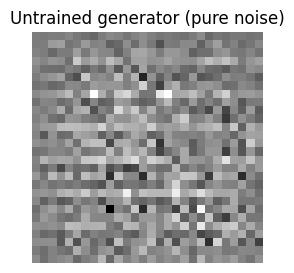

In [ ]:
def build_generator(noise_dim=100):
    model = tf.keras.Sequential(name="Generator")

    # Project and reshape: noise vector -> 7x7 feature map
    model.add(layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(noise_dim,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Reshape((7, 7, 256)))
    # Output shape: (None, 7, 7, 256)

    # Upsampling block 1: 7x7 -> 7x7 (stride=1, deepen features)
    model.add(layers.Conv2DTranspose(128, kernel_size=5, strides=1, padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))
    # Output shape: (None, 7, 7, 128)

    # Upsampling block 2: 7x7 -> 14x14 (stride=2, resolution x2)
    model.add(layers.Conv2DTranspose(64, kernel_size=5, strides=2, padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(0.2))
    # Output shape: (None, 14, 14, 64)

    # Upsampling block 3: 14x14 -> 28x28, single channel (grayscale)
    # tanh activation -> values in [-1, 1], consistent with data normalization
    model.add(layers.Conv2DTranspose(1, kernel_size=5, strides=2, padding='same', use_bias=False, activation='tanh'))
    # Output shape: (None, 28, 28, 1)

    return model


NOISE_DIM = 100
generator = build_generator(NOISE_DIM)
generator.summary()

# untrained generator produces visual noise
test_noise = tf.random.normal([1, NOISE_DIM])
test_gen = generator(test_noise, training=False)
print(f"\nGenerator output shape: {test_gen.shape}")

plt.figure(figsize=(3, 3))
plt.imshow(test_gen[0, :, :, 0], cmap='gray')
plt.title("Untrained generator (pure noise)")
plt.axis('off')
plt.show()

## Build the discriminator

In [ ]:
def build_discriminator():
    model = tf.keras.Sequential(name="Discriminator")

    # Layer 1: coarse feature extraction, stride=2 -> spatial downsampling
    model.add(layers.Conv2D(64, kernel_size=5, strides=2, padding='same', input_shape=(28, 28, 1)))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))   # regularization: prevents discriminator dominance
    # Output shape: (None, 14, 14, 64)

    # Layer 2: fine feature extraction, stride=2 -> spatial downsampling
    model.add(layers.Conv2D(128, kernel_size=5, strides=2, padding='same'))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))
    # Output shape: (None, 7, 7, 128)

    # Binary classification head
    model.add(layers.Flatten())
    model.add(layers.Dense(1))
    # Output shape: (None, 1)

    return model


discriminator = build_discriminator()
discriminator.summary()

# discriminator evaluates the generated image (untrained -> ~0.5 probability)
test_decision = discriminator(test_gen, training=False)
prob = tf.sigmoid(test_decision).numpy()[0][0]
print(f"\nDiscriminator output (untrained): logit={test_decision.numpy()[0][0]:.4f}, "f"P(real)={prob:.4f}")


/home/muffindud/Documents/RNIP/lab5/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)


Discriminator output (untrained): logit=-0.0026, P(real)=0.4993


## Loss functions and optimizers

In [ ]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)


def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)

    return real_loss + fake_loss


def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)


generator_optimizer     = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.5)


In [ ]:
@tf.function
def train_step(image_batch):
    # Sample random noise vectors — one per image in the batch
    noise = tf.random.normal([tf.shape(image_batch)[0], NOISE_DIM])

    # Record operations for gradient computation
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        # Generator produces fake images
        fake_images = generator(noise, training=True)

        # Discriminator evaluates both real and fake
        real_output = discriminator(image_batch, training=True)
        fake_output = discriminator(fake_images, training=True)

        # Compute losses for both networks
        gen_loss  = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    # Compute gradients with respect to each network's parameters
    gen_gradients  = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    # Apply gradient updates
    generator_optimizer.apply_gradients(
        zip(gen_gradients, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(
        zip(disc_gradients, discriminator.trainable_variables))

    return gen_loss, disc_loss


def save_generated_images(epoch, test_noise, save_dir="generated"):
    os.makedirs(save_dir, exist_ok=True)
    generated = generator(test_noise, training=False)

    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    fig.suptitle(f"Epoch {epoch:03d} — Fashion-MNIST GAN", fontsize=13, fontweight='bold', y=1.01)
    for i, ax in enumerate(axes.flat):
        # Denormalize from [-1,1] back to [0,255] for display
        img = generated[i, :, :, 0] * 127.5 + 127.5
        ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(f"{save_dir}/epoch_{epoch:03d}.png", dpi=100, bbox_inches='tight')
    plt.close()


def train_gan(dataset, epochs):
    # Fixed noise vectors for consistent visual progress tracking
    fixed_noise = tf.random.normal([16, NOISE_DIM])

    gen_losses  = []
    disc_losses = []

    print("\n" + "=" * 60)
    print("GAN TRAINING — Fashion-MNIST DCGAN")
    print("=" * 60)

    for epoch in range(1, epochs + 1):
        start = time.time()
        epoch_gen_loss  = []
        epoch_disc_loss = []

        for batch in dataset:
            g_loss, d_loss = train_step(batch)
            epoch_gen_loss.append(g_loss.numpy())
            epoch_disc_loss.append(d_loss.numpy())

        avg_g = np.mean(epoch_gen_loss)
        avg_d = np.mean(epoch_disc_loss)
        gen_losses.append(avg_g)
        disc_losses.append(avg_d)

        elapsed = time.time() - start
        print(f"Epoch {epoch:3d}/{epochs} | "f"G_loss: {avg_g:.4f} | D_loss: {avg_d:.4f} | "f"Time: {elapsed:.1f}s")

        # Save generated images every 10 epochs and at the final epoch
        if epoch % 10 == 0 or epoch == epochs:
            save_generated_images(epoch, fixed_noise)
            print(f"  -> Images saved for epoch {epoch}")

    return gen_losses, disc_losses


EPOCHS = 100

gen_losses, disc_losses = train_gan(dataset, EPOCHS)



GAN TRAINING — Fashion-MNIST DCGAN


E0000 00:00:1779023665.376511   40019 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inDiscriminator_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Epoch   1/100 | G_loss: 0.6519 | D_loss: 1.3102 | Time: 9.8s
Epoch   2/100 | G_loss: 0.6964 | D_loss: 1.3617 | Time: 5.1s
Epoch   3/100 | G_loss: 0.7093 | D_loss: 1.3720 | Time: 5.2s
Epoch   4/100 | G_loss: 0.7215 | D_loss: 1.3552 | Time: 8.1s
Epoch   5/100 | G_loss: 0.7419 | D_loss: 1.3248 | Time: 5.4s
Epoch   6/100 | G_loss: 0.7633 | D_loss: 1.3019 | Time: 5.1s
Epoch   7/100 | G_loss: 0.7702 | D_loss: 1.2942 | Time: 5.1s
Epoch   8/100 | G_loss: 0.7661 | D_loss: 1.3026 | Time: 5.2s
Epoch   9/100 | G_loss: 0.7591 | D_loss: 1.3172 | Time: 5.2s
Epoch  10/100 | G_loss: 0.7505 | D_loss: 1.3278 | Time: 7.8s
  -> Images saved for epoch 10
Epoch  11/100 | G_loss: 0.7418 | D_loss: 1.3351 | Time: 5.3s
Epoch  12/100 | G_loss: 0.7437 | D_loss: 1.3345 | Time: 5.0s
Epoch  13/100 | G_loss: 0.7472 | D_loss: 1.3301 | Time: 5.3s
Epoch  14/100 | G_loss: 0.7439 | D_loss: 1.3345 | Time: 5.3s
Epoch  15/100 | G_loss: 0.7428 | D_loss: 1.3377 | Time: 5.0s
Epoch  16/100 | G_loss: 0.7422 | D_loss: 1.3357 | Time

## Evaluate results

### Loss curves

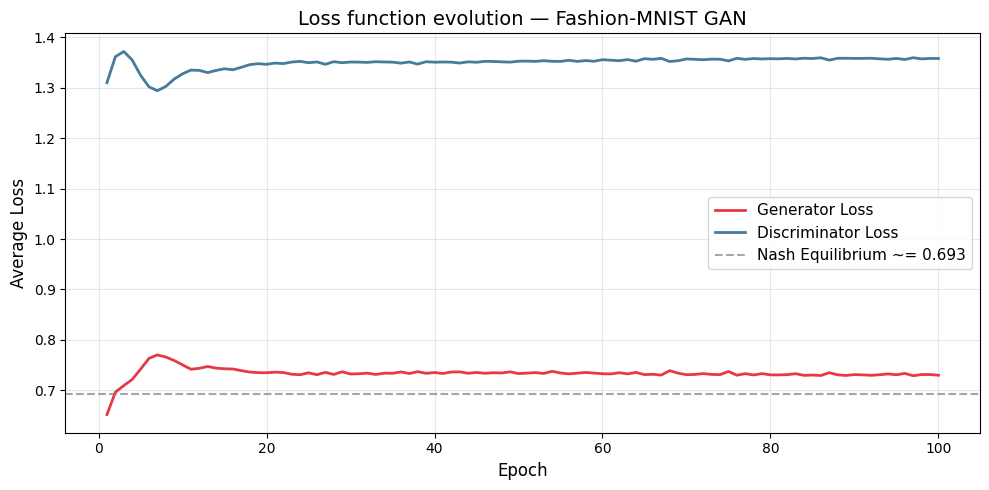


Final Generator loss:      0.7299
Final Discriminator loss:  1.3581
Nash Equilibrium target:   0.6931


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, EPOCHS + 1), gen_losses,  label='Generator Loss', color='#E63946', linewidth=2)
ax.plot(range(1, EPOCHS + 1), disc_losses, label='Discriminator Loss', color='#457B9D', linewidth=2)
ax.axhline(y=np.log(2), color='gray', linestyle='--', alpha=0.7, label=f'Nash Equilibrium ~= {np.log(2):.3f}')
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Average Loss", fontsize=12)
ax.set_title("Loss function evolution — Fashion-MNIST GAN", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFinal Generator loss:      {gen_losses[-1]:.4f}")
print(f"Final Discriminator loss:  {disc_losses[-1]:.4f}")
print(f"Nash Equilibrium target:   {np.log(2):.4f}")


### Final generated images

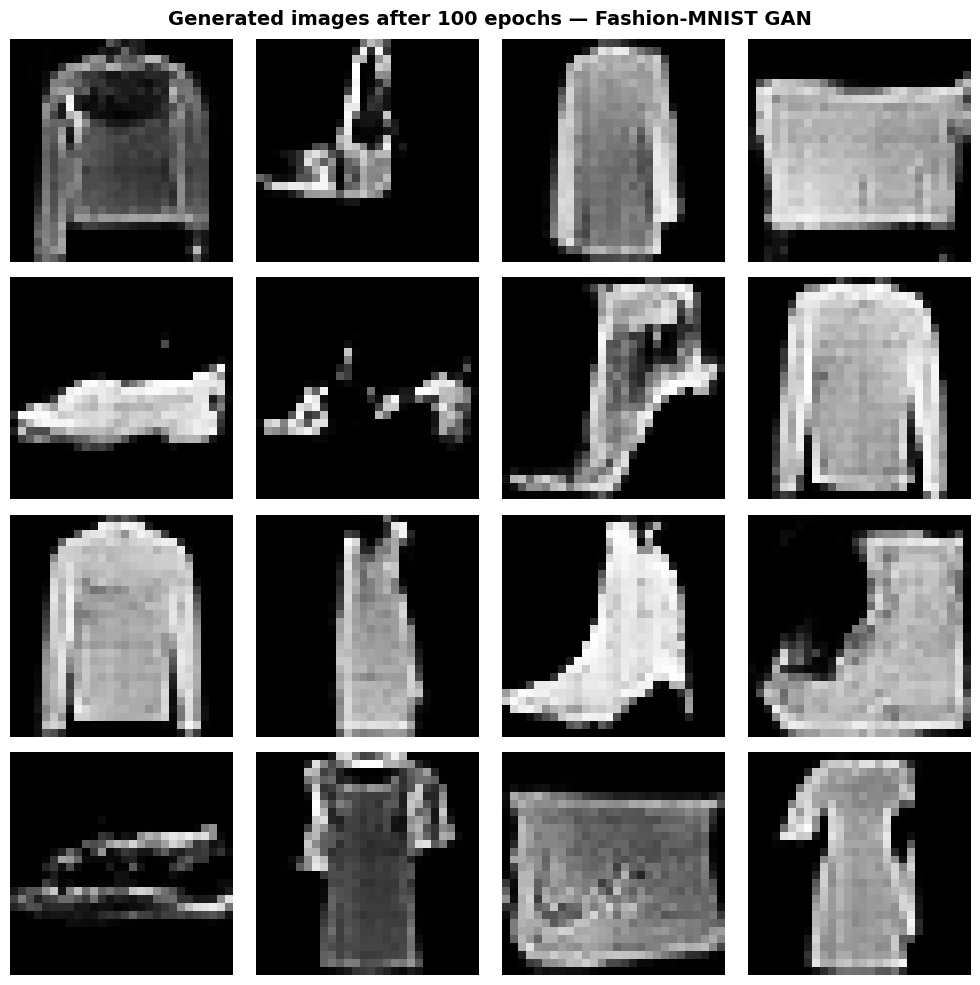

In [ ]:
final_noise  = tf.random.normal([16, NOISE_DIM])
final_images = generator(final_noise, training=False)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle(f"Generated images after {EPOCHS} epochs — Fashion-MNIST GAN", fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    img = final_images[i, :, :, 0] * 127.5 + 127.5
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.axis('off')
plt.tight_layout()
plt.show()

### Real vs. generated images

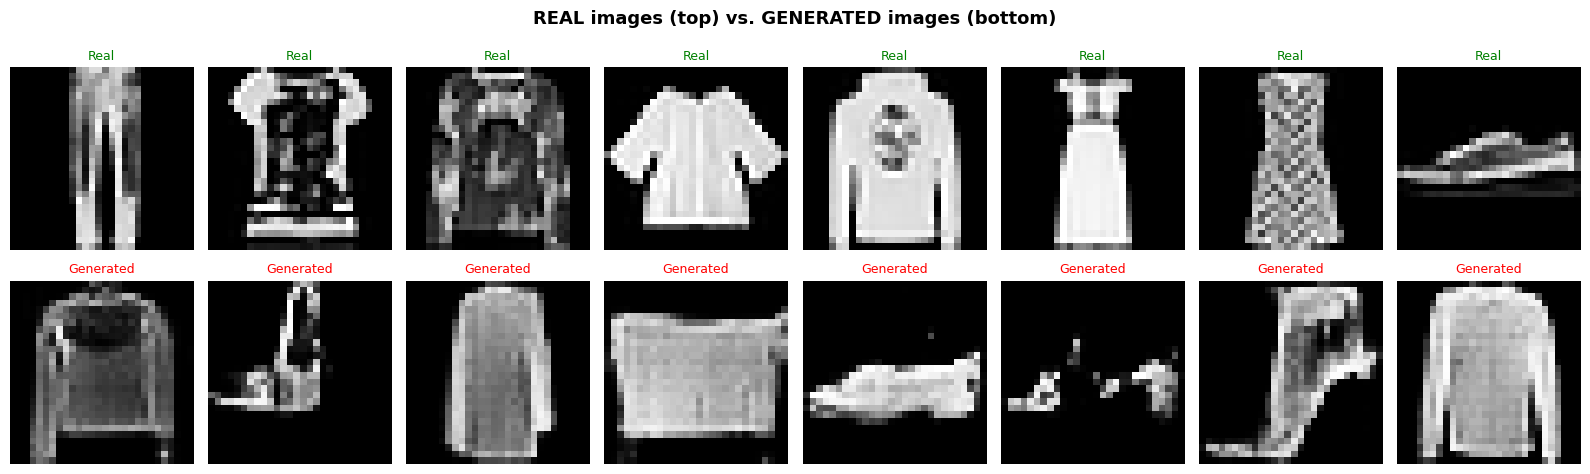


TRAINING COMPLETE
Saved files:
  real_samples.png        — real examples from the dataset
  generator_untrained.png — generator output before training
  generated/epoch_*.png   — visual progress per checkpoint
  loss_curves.png         — loss evolution over epochs
  final_generated.png     — final generated images grid
  real_vs_generated.png   — side-by-side comparison


In [ ]:
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle("REAL images (top) vs. GENERATED images (bottom)", fontsize=13, fontweight='bold')
for i in range(8):
    # real images
    idx = np.random.randint(0, len(X_train))
    real_img = (X_train[idx, :, :, 0] * 127.5 + 127.5)
    axes[0, i].imshow(real_img, cmap='gray', vmin=0, vmax=255)
    axes[0, i].set_title("Real", fontsize=9, color='green')
    axes[0, i].axis('off')

    # generated images
    gen_img = final_images[i, :, :, 0] * 127.5 + 127.5
    axes[1, i].imshow(gen_img.numpy(), cmap='gray', vmin=0, vmax=255)
    axes[1, i].set_title("Generated", fontsize=9, color='red')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("Saved files:")
print("  real_samples.png        — real examples from the dataset")
print("  generator_untrained.png — generator output before training")
print("  generated/epoch_*.png   — visual progress per checkpoint")
print("  loss_curves.png         — loss evolution over epochs")
print("  final_generated.png     — final generated images grid")
print("  real_vs_generated.png   — side-by-side comparison")
print("=" * 60)
